# Pairwise Independence vs Mutual Independence
## Introduction
In probability theory, there's an important distinction between pairwise independence and mutual independence that is often overloaded.
## Definitions
**Pairwise Independence:** Random variables $X_1, X_2, .. ,X_n$ are pairwise independent if every pair is independent:
$$P(X_i,X_j)= P(X_i) \cdot P(X_j) \quad \text{for all} i \neq j$$

**Mutual Independence:** Random variables $X_1, X_2, ..., X_n$ are mutually independent if for EVERY SUBSET $S \subseteq \{1,2,...,n\}$:
$$P\left(\bigcap_{i \in S} X_i\right)= \prod_{i \in S} P(X_i)$$

### Key insights:
**Mutual independence implies pairwise independence, but not vice versa!**
This notebook would demonstrate a classic contrexample: random variables that are pairwise independent but not mutually independent:


# Import required libraries

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from itertools import product, combinations #to generate combinations
# set random seed for reproducibility
np.random.seed(42)
#set plot style
plt.style.use('seaborn-v0_8-whitegrid')

## Define the classic contrexample

We construct three binary random variables:
- **X**: Fair coin flip (0 or 1 with equal possibility)
- **Y**: Fair coin flip (0 or 1 with equal possibility), independent of X
- **Z**: XOR of X and Y, i.e. , $Z = X \oplus Y$

## Why does this work?
- Each variable individually is uniform: $P(X=0)=P(X=1)=0.5$, same for Y and Z
- Any twi variables are independent ( we'll verify this empirically)
- They can't mutually independent, given that by having X and Y, Z is completely determined

In [4]:
def generate_sample_space(n_trials):
    """
    Generate the sample space for a given set of events where X and Y are independent fair coin flips and Z = X XOR Y
    """
    X = np.random.randint(0, 2, size=n_trials)  # 0 or 1 for X
    Y = np.random.randint(0, 2, size=n_trials)  # 0 or 1 for Y
    Z = X ^ Y  # XOR operation
    return X, Y, Z
# generate large nbr of samples
N_TRIALS = 100_000
X, Y, Z = generate_sample_space(N_TRIALS)

print(f"Sample space generated with {N_TRIALS} trials.")
print(f"\n First 10 samples of X: {X[:10]}")
print(f"First 10 samples of Y: {Y[:10]}")
print(f"First 10 samples of Z: {Z[:10]}")

Sample space generated with 100000 trials.

 First 10 samples of X: [0 1 0 0 0 1 0 0 0 1]
First 10 samples of Y: [0 1 1 1 1 1 0 0 0 1]
First 10 samples of Z: [0 0 1 1 1 0 0 0 0 0]


## Verifying marginal distributions
First, let's verufy that each random variable individually had a uniform distribution(probability 0.5 for each outcome)

In [5]:
def compute_marginal_probs(samples):
    """ comput P(V=0) and P(V=1) for a given variable V """
    return np.mean(samples == 0), np.mean(samples == 1)

print("\nMarginal Probabilities")
print("="*50)
for name, var in [('X',X), ('Y',Y), ('Z',Z)]:
    p0, p1 = compute_marginal_probs(var)
    print(f"P({name}=0) = {p0:.4f}, P({name}=1) = {p1:.4f}")


Marginal Probabilities
P(X=0) = 0.4994, P(X=1) = 0.5006
P(Y=0) = 0.5014, P(Y=1) = 0.4986
P(Z=0) = 0.5016, P(Z=1) = 0.4984


## Empirically, verifying the pairwise independence
For pairwise independence, we need to verify that for each pair (A,B):
$$P(A=a, B=b)=P(A=a) \cdot P(B=b) \quad \text{for all values}a,b $$
Checking all three pairs: (X,Y), (Y,Z), (X,Z)

In [7]:
def check_pairwise_independence(var1,var2, name1, name2):
    """Checking if two binary variables are independent by comparing joint probabilities to product marginales"""
    print(f"\nChecking independence between {name1} and {name2}")
    print("="*50)
    results = []
    for a in [0,1]:
        for b in [0,1]:
            joint_prob = np.mean((var1 == a) & (var2 == b))
            marginal_prob = np.mean(var1 == a) * np.mean(var2 == b)
            diff = abs(joint_prob - marginal_prob)
            print(f"P({name1}={a}, {name2}={b}) = {joint_prob:.4f}, P({name1}={a})*P({name2}={b}) = {marginal_prob:.4f}, Difference: {diff:.4e}")
            results.append((joint_prob,marginal_prob,diff))

    max_diff = max(r[2] for r in results)
    print(f"\nMaximum difference observed: {max_diff:.6f}")
    print(f"Conclusion:{'Independent' if max_diff < 0.01 else 'Not Independent'} ")
    return results
#Check all pairs for independence
print("="*50)
print("\nPairwise Independence Checks")
print("="*50)
results_XY = check_pairwise_independence(X,Y,'X','Y')
results_XZ = check_pairwise_independence(X,Z,'X','Z')
results_YZ = check_pairwise_independence(Y,Z,'Y','Z')


Pairwise Independence Checks

Checking independence between X and Y
P(X=0, Y=0) = 0.2512, P(X=0)*P(Y=0) = 0.2504, Difference: 7.9088e-04
P(X=0, Y=1) = 0.2482, P(X=0)*P(Y=1) = 0.2490, Difference: 7.9088e-04
P(X=1, Y=0) = 0.2502, P(X=1)*P(Y=0) = 0.2510, Difference: 7.9088e-04
P(X=1, Y=1) = 0.2504, P(X=1)*P(Y=1) = 0.2496, Difference: 7.9088e-04

Maximum difference observed: 0.000791
Conclusion:Independent 

Checking independence between X and Z
P(X=0, Z=0) = 0.2512, P(X=0)*P(Z=0) = 0.2505, Difference: 6.9600e-04
P(X=0, Z=1) = 0.2482, P(X=0)*P(Z=1) = 0.2489, Difference: 6.9600e-04
P(X=1, Z=0) = 0.2504, P(X=1)*P(Z=0) = 0.2511, Difference: 6.9600e-04
P(X=1, Z=1) = 0.2502, P(X=1)*P(Z=1) = 0.2495, Difference: 6.9600e-04

Maximum difference observed: 0.000696
Conclusion:Independent 

Checking independence between Y and Z
P(Y=0, Z=0) = 0.2512, P(Y=0)*P(Z=0) = 0.2515, Difference: 3.1720e-04
P(Y=0, Z=1) = 0.2502, P(Y=0)*P(Z=1) = 0.2499, Difference: 3.1720e-04
P(Y=1, Z=0) = 0.2504, P(Y=1)*P(Z=0) =

## Showing the failure of mutual independence 
For mutual independence, we need:
$$P(X=x,Y=y,Z=z)= P(X=x) \cdot P(Y=y) \cdot P(Z=z) \quad for all x,y,z $$
However, since $ Z = X \oplus Y $ we know that:
- $P(X=0, Y=0, Z=1)=0$ (impossible since $0 \oplus 0 = 0$)
- But $P(X=0) \cdot P(Y=0) \cdot P(Z=1) = 0.5 * 0.5 * 0.5 = 0.125$

This is a violation of mutual independence

In [8]:
def check_mutual_independence(X,Y,Z):
    """Check if three variables are mutually independent by comparing joint probabilities to product of marginals"""
    print("="*50)
    print("\nMUTUAL INDEPENCENCE CHECK")
    print("="*50)
    results = []
    for a in [0,1]:
        for b in [0,1]:
            for c in [0,1]:
                joint_prob = np.mean((X == a) & (Y == b) & (Z == c))
                marginal_prob = np.mean(X == a) * np.mean(Y == b) * np.mean(Z == c)
                diff = abs(joint_prob - marginal_prob)
                status = "Independent" if diff < 0.01 else "Not Independent"
                print(f"P(X={a}, Y={b}, Z={c}) = {joint_prob:.4f}, P(X={a})*P(Y={b})*P(Z={c}) = {marginal_prob:.4f}, Difference: {diff:.4e} {status}")
                results.append({'x':a, 'y':b, 'z':c, "joint_prob": joint_prob, "marginal_prob": marginal_prob, "diff": diff})

    max_diff = max(r["diff"] for r in results)
    print(f"\nMaximum difference observed: {max_diff:.6f}")
    print(f"Conclusion:{'Mutually Independent' if max_diff < 0.01 else 'Not Mutually Independent'} ")
    return results
mutual_independence_results = check_mutual_independence(X,Y,Z)


MUTUAL INDEPENCENCE CHECK
P(X=0, Y=0, Z=0) = 0.2512, P(X=0)*P(Y=0)*P(Z=0) = 0.1256, Difference: 1.2558e-01 Not Independent
P(X=0, Y=0, Z=1) = 0.0000, P(X=0)*P(Y=0)*P(Z=1) = 0.1248, Difference: 1.2479e-01 Not Independent
P(X=0, Y=1, Z=0) = 0.0000, P(X=0)*P(Y=1)*P(Z=0) = 0.1249, Difference: 1.2489e-01 Not Independent
P(X=0, Y=1, Z=1) = 0.2482, P(X=0)*P(Y=1)*P(Z=1) = 0.1241, Difference: 1.2410e-01 Not Independent
P(X=1, Y=0, Z=0) = 0.0000, P(X=1)*P(Y=0)*P(Z=0) = 0.1259, Difference: 1.2590e-01 Not Independent
P(X=1, Y=0, Z=1) = 0.2502, P(X=1)*P(Y=0)*P(Z=1) = 0.1251, Difference: 1.2511e-01 Not Independent
P(X=1, Y=1, Z=0) = 0.2504, P(X=1)*P(Y=1)*P(Z=0) = 0.1252, Difference: 1.2521e-01 Not Independent
P(X=1, Y=1, Z=1) = 0.0000, P(X=1)*P(Y=1)*P(Z=1) = 0.1244, Difference: 1.2442e-01 Not Independent

Maximum difference observed: 0.125902
Conclusion:Not Mutually Independent 


## VISUALIZATION

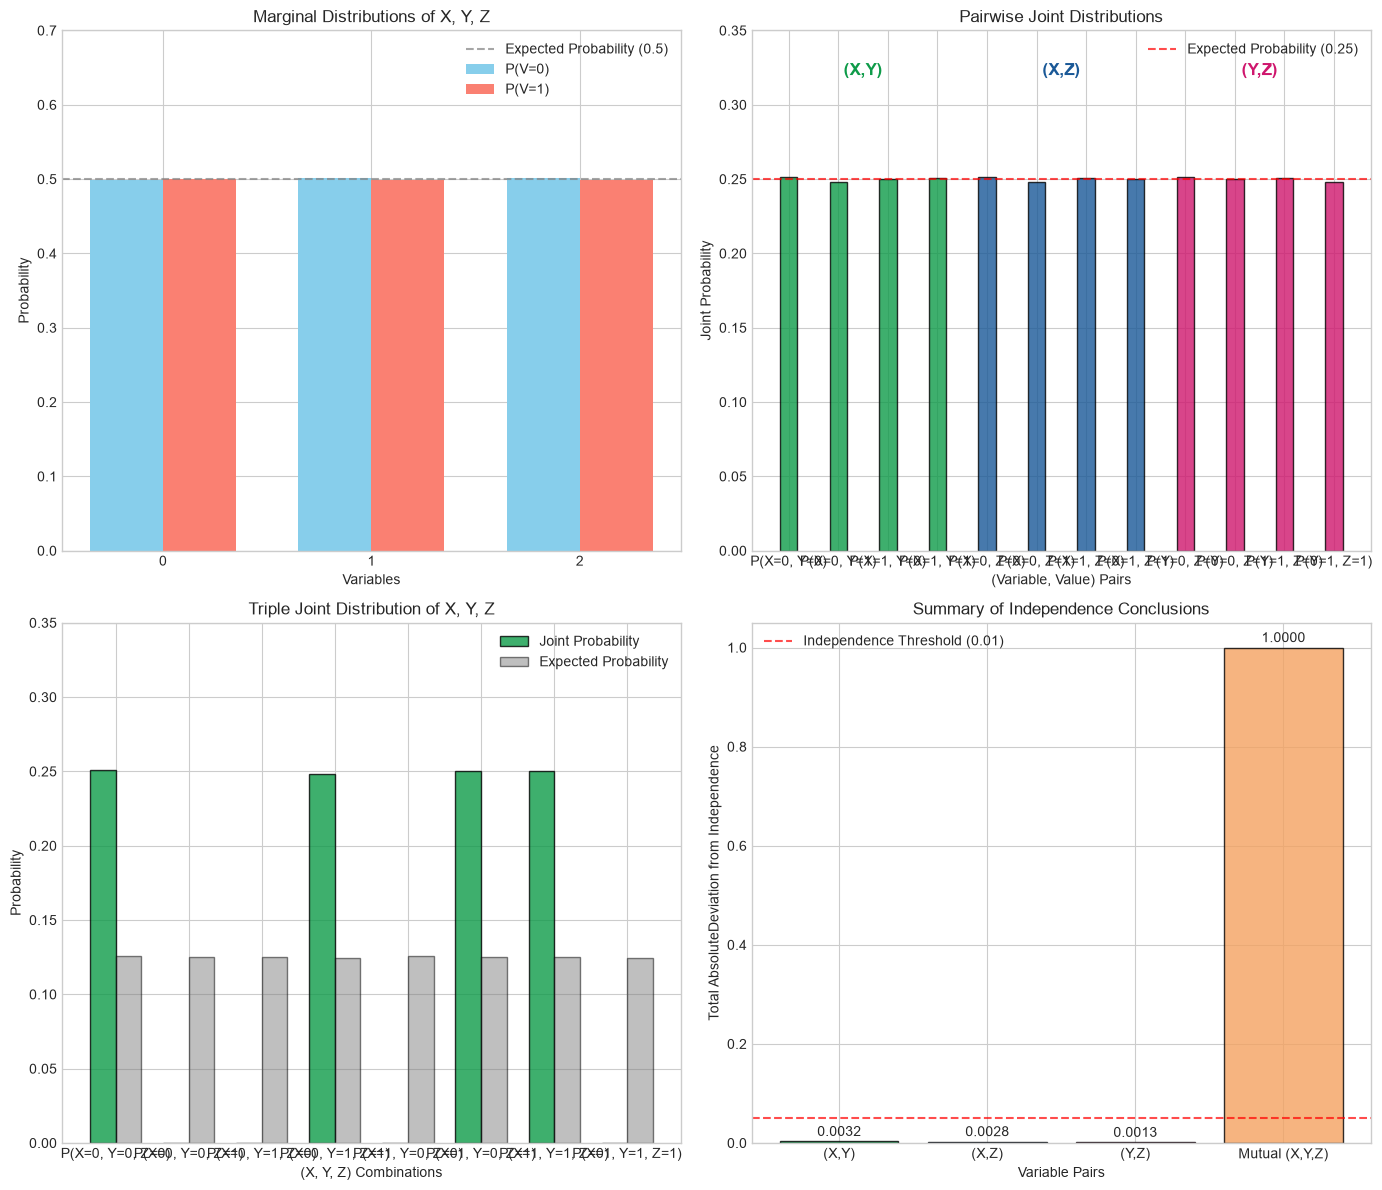


Visualization Saved!


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
#plot 1: marginal distributions
ax1 = axes[0, 0]
variables = ['X', 'Y', 'Z']
p_zeros = [np.mean(X==0), np.mean(Y==0), np.mean(Z==0)]
p_ones = [np.mean(X==1), np.mean(Y==1), np.mean(Z==1)]

x_pos = np.arange(len(variables))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, p_zeros, width, label='P(V=0)', color='skyblue')
bars2 = ax1.bar(x_pos + width/2, p_ones, width, label='P(V=1)', color='salmon')
ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Expected Probability (0.5)')
ax1.set_xlabel('Variables')
ax1.set_ylabel('Probability')
ax1.set_title('Marginal Distributions of X, Y, Z')
ax1.set_xticks(x_pos)
ax1.legend()
ax1.set_ylim(0, 0.7)

# plot 2: pairwise joint distributions
ax2 = axes[0, 1]
pairs = [('X', 'Y', X, Y), ('X', 'Z', X, Z), ('Y', 'Z', Y, Z)]
pair_labels = []
joint_probs = []
expected_probs = []
for name1, name2, var1, var2 in pairs:
    for a in [0, 1]:
        for b in [0, 1]:
            joint_prob = np.mean((var1 == a) & (var2 == b))
            expected_prob = np.mean(var1 == a) * np.mean(var2 == b)
            pair_labels.append(f"P({name1}={a}, {name2}={b})")
            joint_probs.append(joint_prob)
            expected_probs.append(expected_prob)
x_pos = np.arange(len(pair_labels))
colors = ["#0e9b49"]*4+["#195897"]*4+["#cf166d"]*4
ax2.bar(x_pos , joint_probs, width, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0.25, color='red', linestyle='--', alpha=0.7, label='Expected Probability (0.25)')
ax2.set_xlabel('(Variable, Value) Pairs')
ax2.set_ylabel('Joint Probability')
ax2.set_title('Pairwise Joint Distributions')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(pair_labels,fontsize=10)
ax2.legend()
ax2.set_ylim(0, 0.35)

# add pair labels
ax2.text(1.5, 0.32, '(X,Y)', ha='center', fontsize=12, fontweight='bold', color='#0e9b49')
ax2.text(5.5, 0.32, '(X,Z)', ha='center', fontsize=12, fontweight='bold', color='#195897')
ax2.text(9.5, 0.32, '(Y,Z)', ha='center', fontsize=12, fontweight='bold', color='#cf166d')

# Plot 3: triple joint distribution
ax3 = axes[1, 0]
triple_labels = []
triple_joint_probs = []
triple_expected_probs = []
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            joint_prob = np.mean((X == a) & (Y == b) & (Z == c))
            expected_prob = np.mean(X == a) * np.mean(Y == b) * np.mean(Z == c)
            triple_labels.append(f"P(X={a}, Y={b}, Z={c})")
            triple_joint_probs.append(joint_prob)
            triple_expected_probs.append(expected_prob)
x_pos = np.arange(len(triple_labels))
width = 0.35

colors = []
for i,(x_val, y_val, z_val) in enumerate(product([0,1],[0,1],[0,1])):
    if z_val == (x_val^y_val):
        colors.append("#0e9b49")  
    else:
        colors.append("#cf166d")  
bars1 = ax3.bar(x_pos - width/2, triple_joint_probs, width, label='Joint Probability', color=colors, alpha=0.8, edgecolor='black')
bars2 = ax3.bar(x_pos + width/2, triple_expected_probs, width, label='Expected Probability', color='gray', alpha=0.5, edgecolor='black')
ax3.set_xlabel('(X, Y, Z) Combinations')
ax3.set_ylabel('Probability')
ax3.set_title('Triple Joint Distribution of X, Y, Z')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(triple_labels, fontsize=10)
ax3.legend(loc='upper right')
ax3.set_ylim(0, 0.35)

# Plot summary of independence conclusions
ax4 = axes[1, 1]
pairwise_devs=[]
for name1, name2, var1, var2 in pairs:
    dev=0
    for a in [0, 1]:
        for b in [0, 1]:
            joint_prob = np.mean((var1 == a) & (var2 == b))
            marginal_prob = np.mean(var1 == a) * np.mean(var2 == b)
            diff = abs(joint_prob - marginal_prob)
            dev += diff
    pairwise_devs.append(dev)

mutual_dev = 0
for a in [0, 1]:
    for b in [0, 1]:
        for c in [0, 1]:
            joint_prob = np.mean((X == a) & (Y == b) & (Z == c))
            marginal_prob = np.mean(X == a) * np.mean(Y == b) * np.mean(Z == c)
            diff = abs(joint_prob - marginal_prob)
            mutual_dev += diff
categories = ['(X,Y)', '(X,Z)', '(Y,Z)', 'Mutual (X,Y,Z)']
deviations = pairwise_devs + [mutual_dev]
colors = ['#0e9b49', '#195897', '#cf166d', '#f4a261']
bars = ax4.bar(categories, deviations, color=colors, alpha=0.8, edgecolor='black')
ax4.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='Independence Threshold (0.01)')
ax4.set_xlabel('Variable Pairs')
ax4.set_ylabel('Total AbsoluteDeviation from Independence')
ax4.set_title('Summary of Independence Conclusions')
ax4.legend()

for bar, dev in zip(bars, deviations):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{dev:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("independence_visualization.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization Saved!")